# Inter-rater Reliability — Max vs. Gemini

Computes **PABAK** (Prevalence-Adjusted Bias-Adjusted Kappa) between Max's human annotations
and Gemini's AI annotations for each behavioral code.

**Approach (binary per-code):**
For each utterance × code pair, we ask: did the rater assign this code? (1 = yes, 0 = no).  
PABAK = 2 × P_o − 1, where P_o = proportion of utterances where both raters agree (both 1 or both 0).  
PABAK ranges from −1 (perfect disagreement) to +1 (perfect agreement).

**Inputs:**
- `analysis_v2/sampling/data/sampled_video_verification_(Max)_v2.xlsx` — Max's annotations (Sheet: Step 1 Annotate)
- `analysis_v2/notebooks/sampled_v2.xlsx` — Gemini's annotations (code_names column)

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── repo root ────────────────────────────────────────────────────────────────
_HERE = os.path.abspath('')
if os.path.basename(_HERE) == 'notebooks':
    os.chdir(os.path.join(_HERE, '..', '..'))
elif os.path.basename(_HERE) == 'analysis_v2':
    os.chdir(os.path.join(_HERE, '..'))
print('Working directory:', os.getcwd())

# ── config ───────────────────────────────────────────────────────────────────
MAX_XLSX   = 'analysis_v2/sampling/data/sampled_video_verification_(Max)_v2.xlsx'
GEMINI_XLSX = 'analysis_v2/notebooks/sampled_v2.xlsx'
OUTPUT_PNG  = 'analysis_v2/notebooks/interrater_pabak.png'
OUTPUT_CSV  = 'analysis_v2/notebooks/interrater_pabak.csv'

# Exclude from reliability analysis (background code annotated incidentally)
EXCLUDE_CODES = {'Pronoun Framing'}

Working directory: /Users/maxchalekson/Projects/NICO-Research/gemini_data_analysis


## 1 · Load Max's annotations

In [2]:
xl = pd.ExcelFile(MAX_XLSX)
df_max_raw = xl.parse('Step 1 Annotate', header=1)

# Forward-fill video column (merged cells in Excel leave NaN)
df_max_raw['video'] = df_max_raw['video'].ffill()

# Rename for clarity
df_max_raw = df_max_raw.rename(columns={
    'video'    : 'chunk_key',
    'timestamp': 'timestamp',
    'speaker'  : 'speaker',
})

# Collect up to 3 annotation columns into a list of codes per row
ann_cols = ['annotation', 'annotation.1', 'annotation.2']

def parse_max_codes(row):
    codes = []
    for col in ann_cols:
        val = row.get(col)
        if pd.notna(val) and str(val).strip():
            codes.append(str(val).strip())
    return codes

df_max_raw['max_codes'] = df_max_raw.apply(parse_max_codes, axis=1)

# Keep only rows with at least one annotation
df_max = df_max_raw[['chunk_key', 'timestamp', 'speaker', 'max_codes']].copy()
df_max = df_max[df_max['max_codes'].map(len) > 0].reset_index(drop=True)

print(f'Max annotations loaded: {len(df_max)} utterances')
print(f'Sample:')
print(df_max.head(5).to_string())

Max annotations loaded: 212 utterances
Sample:
                  chunk_key    timestamp                speaker                                                               max_codes
0  Bot4_MND_2022_1_4_chunk8  00:00-00:10  Rosa Krajmalnik-Brown             [Broader Significance, Coordination and Decision Practices]
1  Bot4_MND_2022_1_4_chunk8  00:10-00:31           Iliyan Iliev  [Broader Significance, Future-Oriented Language, Evaluation Practices]
2  Bot4_MND_2022_1_4_chunk7  01:18-01:41  Rosa Krajmalnik-Brown                           [Participation Dynamics, Information Seeking]
3  Bot4_MND_2022_1_4_chunk7  02:23-02:52  Rosa Krajmalnik-Brown     [Integration Practices, Participation Dynamics, Relational Climate]
4  Bot4_MND_2022_1_4_chunk6  00:28-01:02        Faranak Fattahi                                                   [Information Seeking]


## 2 · Load Gemini's annotations

In [3]:
df_gm = pd.read_excel(GEMINI_XLSX)

# chunk_key: strip .json from chunk_file to match Max's video column
df_gm['chunk_key'] = df_gm['chunk_file'].str.replace('.json', '', regex=False)

# Parse pipe-separated code_names
def parse_gemini_codes(val):
    if pd.isna(val) or not str(val).strip():
        return []
    return [c.strip() for c in str(val).split('|') if c.strip()]

df_gm['gemini_codes'] = df_gm['code_names'].apply(parse_gemini_codes)

df_gm = df_gm[['chunk_key', 'timestamp', 'speaker', 'gemini_codes']].copy()

print(f'Gemini annotations loaded: {len(df_gm)} utterances')
print(f'Sample:')
print(df_gm.head(5).to_string())

Gemini annotations loaded: 226 utterances
Sample:
                  chunk_key    timestamp                speaker                                                gemini_codes
0  Bot4_MND_2022_1_4_chunk8  00:00-00:10  Rosa Krajmalnik-Brown  [Knowledge Sharing, Broader Significance, Pronoun Framing]
1  Bot4_MND_2022_1_4_chunk8  00:10-00:31           Iliyan Iliev  [Knowledge Sharing, Broader Significance, Pronoun Framing]
2  Bot4_MND_2022_1_4_chunk7  01:18-01:41  Rosa Krajmalnik-Brown            [Participation Dynamics, Participation Dynamics]
3  Bot4_MND_2022_1_4_chunk7  02:23-02:52  Rosa Krajmalnik-Brown  [Idea Management, Pronoun Framing, Participation Dynamics]
4  Bot4_MND_2022_1_4_chunk6  00:28-01:02        Faranak Fattahi                  [Information Seeking, Information Seeking]


## 3 · Merge on chunk_key + timestamp + speaker

In [4]:
merged = pd.merge(
    df_max, df_gm,
    on=['chunk_key', 'timestamp', 'speaker'],
    how='inner'
)

print(f'Merged utterances: {len(merged)}')
print(f'Unmatched Max rows : {len(df_max) - len(merged)}')
print(f'Unmatched Gemini rows: {len(df_gm) - len(merged)}')
print()
print(merged[['chunk_key','timestamp','speaker','max_codes','gemini_codes']].head(5).to_string())

Merged utterances: 212
Unmatched Max rows : 0
Unmatched Gemini rows: 14

                  chunk_key    timestamp                speaker                                                               max_codes                                                gemini_codes
0  Bot4_MND_2022_1_4_chunk8  00:00-00:10  Rosa Krajmalnik-Brown             [Broader Significance, Coordination and Decision Practices]  [Knowledge Sharing, Broader Significance, Pronoun Framing]
1  Bot4_MND_2022_1_4_chunk8  00:10-00:31           Iliyan Iliev  [Broader Significance, Future-Oriented Language, Evaluation Practices]  [Knowledge Sharing, Broader Significance, Pronoun Framing]
2  Bot4_MND_2022_1_4_chunk7  01:18-01:41  Rosa Krajmalnik-Brown                           [Participation Dynamics, Information Seeking]            [Participation Dynamics, Participation Dynamics]
3  Bot4_MND_2022_1_4_chunk7  02:23-02:52  Rosa Krajmalnik-Brown     [Integration Practices, Participation Dynamics, Relational Climate]  [Idea 

## 4 · Build binary code matrix

In [5]:
# All unique codes across both raters (excluding background codes)
all_codes = set()
for codes in merged['max_codes']:
    all_codes.update(codes)
for codes in merged['gemini_codes']:
    all_codes.update(codes)
all_codes -= EXCLUDE_CODES
all_codes = sorted(all_codes)

print(f'Unique codes to evaluate: {len(all_codes)}')
for c in all_codes:
    print(f'  {c}')

# Binary matrix: rows = utterances, cols = codes, values = 1/0 per rater
rows = []
for _, row in merged.iterrows():
    max_set    = set(row['max_codes'])    - EXCLUDE_CODES
    gemini_set = set(row['gemini_codes']) - EXCLUDE_CODES
    entry = {
        'chunk_key': row['chunk_key'],
        'timestamp': row['timestamp'],
        'speaker'  : row['speaker'],
    }
    for code in all_codes:
        entry[f'max_{code}']    = int(code in max_set)
        entry[f'gemini_{code}'] = int(code in gemini_set)
    rows.append(entry)

binary_df = pd.DataFrame(rows)
print(f'\nBinary matrix shape: {binary_df.shape}')

Unique codes to evaluate: 20
  Broader Significance
  Complementarity Articulation
  Coordination and Decision Practices
  Epistemic Bridging
  Evaluation Practices
  Future-Oriented Language
  Idea Management
  Idea Novelty Signal
  Idea Ownership
  Idea Ownership and Attribution
  Information Seeking
  Information Sharing
  Integration Practices
  Knowledge Sharing
  NA (please provide explanation)
  Participation Dynamics
  Prior Relationship Signal
  Relational Climate
  Role Anticipation
  ambiguous

Binary matrix shape: (212, 43)


## 5 · Compute PABAK per code

**PABAK** = 2 × P_o − 1  
where P_o = proportion of utterances where Max and Gemini agree (both assigned or both didn't assign the code).

Benchmarks: < 0.20 slight, 0.20–0.40 fair, 0.40–0.60 moderate, 0.60–0.80 substantial, > 0.80 almost perfect.

In [6]:
def pabak(y_max, y_gemini):
    """PABAK for binary ratings: 2*P_o - 1."""
    y_max    = np.array(y_max)
    y_gemini = np.array(y_gemini)
    n = len(y_max)
    if n == 0:
        return np.nan
    agree = np.sum(y_max == y_gemini)
    p_o   = agree / n
    return 2 * p_o - 1

results = []
for code in all_codes:
    y_max    = binary_df[f'max_{code}'].values
    y_gemini = binary_df[f'gemini_{code}'].values
    
    p_o  = np.mean(y_max == y_gemini)
    pk   = pabak(y_max, y_gemini)
    n_max    = int(y_max.sum())
    n_gemini = int(y_gemini.sum())
    
    results.append({
        'code'         : code,
        'pabak'        : round(pk, 3),
        'pct_agreement': round(p_o * 100, 1),
        'n_max'        : n_max,
        'n_gemini'     : n_gemini,
        'n_utterances' : len(y_max),
    })

pabak_df = pd.DataFrame(results).sort_values('pabak', ascending=False)
pabak_df.to_csv(OUTPUT_CSV, index=False)
print(pabak_df.to_string(index=False))

                               code  pabak  pct_agreement  n_max  n_gemini  n_utterances
                Idea Novelty Signal  0.991           99.5      0         1           212
          Prior Relationship Signal  0.991           99.5      0         1           212
                Information Sharing  0.991           99.5      1         0           212
                     Idea Ownership  0.991           99.5      0         1           212
                          ambiguous  0.981           99.1      0         2           212
       Complementarity Articulation  0.887           94.3      0        12           212
               Broader Significance  0.868           93.4     11        19           212
     Idea Ownership and Attribution  0.858           92.9      5        12           212
                  Role Anticipation  0.840           92.0      0        17           212
    NA (please provide explanation)  0.811           90.6     20         0           212
           Future-Ori

## 6 · Visualise PABAK per code

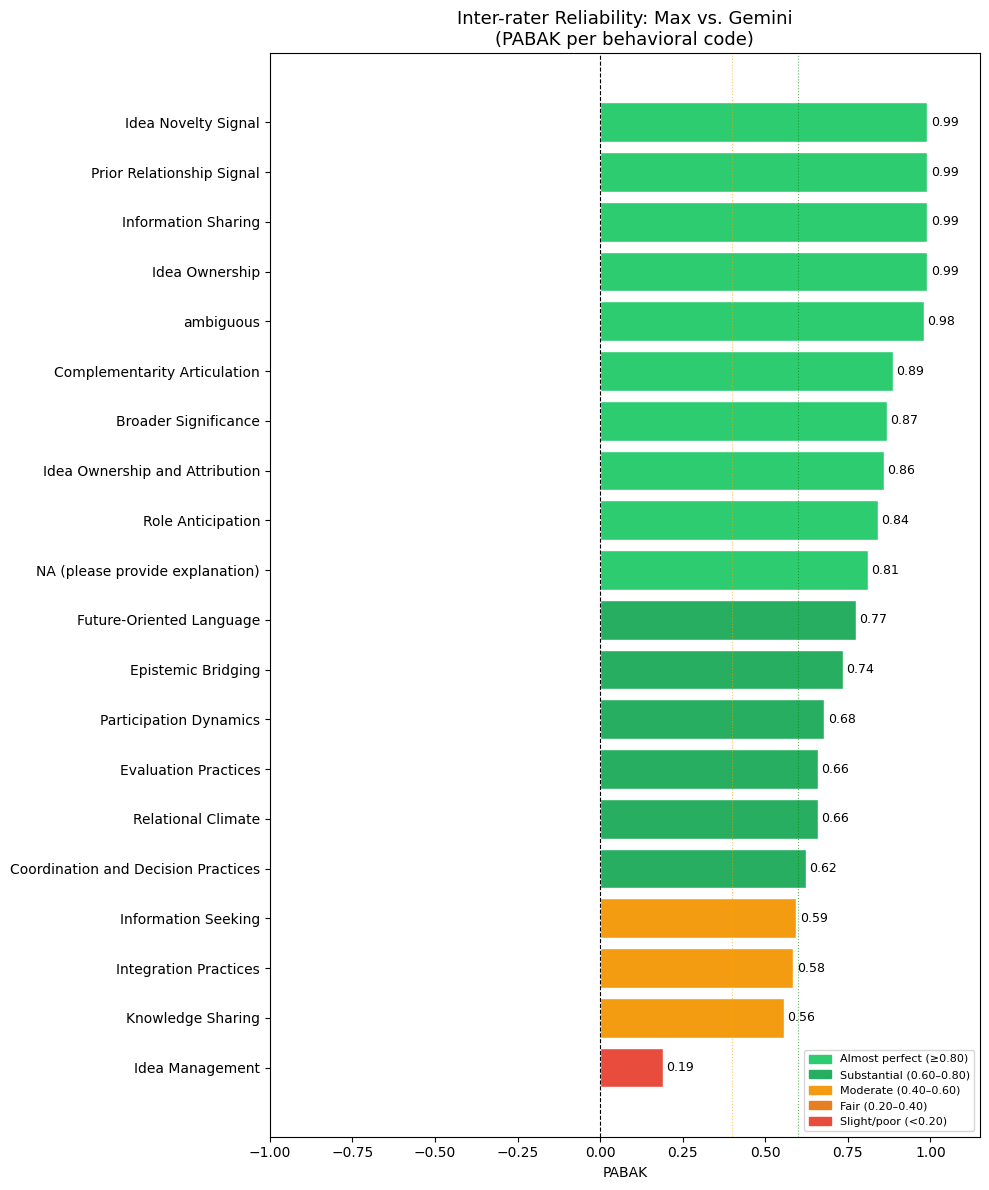

Saved → analysis_v2/notebooks/interrater_pabak.png


In [7]:
def pabak_color(val):
    if val >= 0.80: return '#2ecc71'   # almost perfect — green
    if val >= 0.60: return '#27ae60'   # substantial — dark green
    if val >= 0.40: return '#f39c12'   # moderate — orange
    if val >= 0.20: return '#e67e22'   # fair — dark orange
    return '#e74c3c'                   # slight/poor — red

plot_df = pabak_df.sort_values('pabak')
colors  = [pabak_color(v) for v in plot_df['pabak']]

fig, ax = plt.subplots(figsize=(10, 0.5 * len(plot_df) + 2))
bars = ax.barh(plot_df['code'], plot_df['pabak'], color=colors, edgecolor='white')

# Annotate bars with PABAK value
for bar, val in zip(bars, plot_df['pabak']):
    ax.text(
        val + 0.01 if val >= 0 else val - 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.2f}',
        va='center', ha='left' if val >= 0 else 'right', fontsize=9
    )

ax.axvline(0,    color='black', linewidth=0.8, linestyle='--')
ax.axvline(0.60, color='green', linewidth=0.8, linestyle=':', alpha=0.6, label='Substantial (0.60)')
ax.axvline(0.40, color='orange', linewidth=0.8, linestyle=':', alpha=0.6, label='Moderate (0.40)')
ax.set_xlim(-1, 1.15)
ax.set_xlabel('PABAK')
ax.set_title('Inter-rater Reliability: Max vs. Gemini\n(PABAK per behavioral code)', fontsize=13)

legend_patches = [
    mpatches.Patch(color='#2ecc71', label='Almost perfect (≥0.80)'),
    mpatches.Patch(color='#27ae60', label='Substantial (0.60–0.80)'),
    mpatches.Patch(color='#f39c12', label='Moderate (0.40–0.60)'),
    mpatches.Patch(color='#e67e22', label='Fair (0.20–0.40)'),
    mpatches.Patch(color='#e74c3c', label='Slight/poor (<0.20)'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_PNG, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {OUTPUT_PNG}')

## 7 · Summary

In [8]:
print('=' * 55)
print('INTER-RATER RELIABILITY SUMMARY')
print('=' * 55)
print(f'Utterances compared : {len(merged)}')
print(f'Codes evaluated     : {len(all_codes)}')
print(f'Excluded            : {EXCLUDE_CODES}')
print()

def label(v):
    if v >= 0.80: return 'Almost perfect'
    if v >= 0.60: return 'Substantial'
    if v >= 0.40: return 'Moderate'
    if v >= 0.20: return 'Fair'
    return 'Slight/poor'

print(f'{"Code":<45} {"PABAK":>6}  {"Agreement":>10}  {"n_Max":>6}  {"n_Gemini":>8}  Level')
print('-' * 95)
for _, row in pabak_df.iterrows():
    print(f"{row['code']:<45} {row['pabak']:>6.3f}  {row['pct_agreement']:>9.1f}%  {row['n_max']:>6}  {row['n_gemini']:>8}  {label(row['pabak'])}")

print()
mean_pabak = pabak_df['pabak'].mean()
print(f'Mean PABAK across all codes: {mean_pabak:.3f} ({label(mean_pabak)})')
print(f'Output CSV : {OUTPUT_CSV}')
print(f'Output PNG : {OUTPUT_PNG}')

INTER-RATER RELIABILITY SUMMARY
Utterances compared : 212
Codes evaluated     : 20
Excluded            : {'Pronoun Framing'}

Code                                           PABAK   Agreement   n_Max  n_Gemini  Level
-----------------------------------------------------------------------------------------------
Idea Novelty Signal                            0.991       99.5%       0         1  Almost perfect
Prior Relationship Signal                      0.991       99.5%       0         1  Almost perfect
Information Sharing                            0.991       99.5%       1         0  Almost perfect
Idea Ownership                                 0.991       99.5%       0         1  Almost perfect
ambiguous                                      0.981       99.1%       0         2  Almost perfect
Complementarity Articulation                   0.887       94.3%       0        12  Almost perfect
Broader Significance                           0.868       93.4%      11        19  Almost per